# Librerías

In [1]:
# Use this initial code to work in the notebook as if it were a module, that 
# is, to be able to export classes and functions from other subpackages.

import os
import sys

package_path = os.path.abspath('.').split(os.sep + 'notebooks')[0]
if package_path not in sys.path:
    sys.path.append(package_path)

%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import dask.array as da
from pathlib import Path
import matplotlib.pyplot as plt

from spectralcrop import PathManager

# Abrir Zarr e inspeccionar

In [ ]:
INTERIM_DATA = PathManager().get_abs_path_folder("interim")
FIGURES_FOLDER = PathManager().get_abs_path_folder("figures")
ZARR_PATH = INTERIM_DATA + "masked_reflectance.zarr"
REPORTS_DIR = INTERIM_DATA + "reports"

def to_numpy(arr):
    return arr.compute() if isinstance(arr.data, da.Array) else arr.values

In [5]:
ds = xr.open_zarr(ZARR_PATH, chunks={"band": 64, "y": 512, "x": 512})

# Variables clave (band,y,x) -> transponer a (y,x,band) para trabajar cómodo
refl_byx = ds["reflectance"].transpose("y", "x", "band")
wavelengths = ds["wavelength"].values.astype(float)
fwhm = ds["fwhm"].values.astype(float)
ndvi = ds["NDVI"]
veg_mask = ds["veg_mask"].astype("bool")
written_bands = ds["written_bands"]

print(refl_byx)
print("wavelengths:", wavelengths.shape, "nm  |  fwhm:", fwhm.shape, "nm")
print("NDVI dims:", ndvi.dims, "veg_mask dims:", veg_mask.dims)

# Consistencias útiles para checklist
wl_min, wl_max = float(np.nanmin(wavelengths)), float(np.nanmax(wavelengths))
b_out = int(refl_byx.sizes["band"])
wb_all_ones = bool(int(to_numpy(written_bands).min()) == 1 and int(to_numpy(written_bands).max()) == 1)
print(f"Bandas exportadas: {b_out}, λ: {wl_min:.1f}–{wl_max:.1f} nm, written_bands all=1? {wb_all_ones}")

C:\Users\JMONTOYA\AppData\Local\Temp\ipykernel_13284\144975827.py:1: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ds = xr.open_zarr(ZARR_PATH, chunks={"band": 64, "y": 512, "x": 512})
C:\Users\JMONTOYA\AppData\Local\Temp\ipykernel_13284\144975827.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "band" starting at index 64. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(ZARR_PATH, chunks={"band": 64, "y": 512, "x": 512})


<xarray.DataArray 'reflectance' (y: 3660, x: 3438, band: 379)> Size: 19GB
dask.array<transpose, shape=(3660, 3438, 379), dtype=float32, chunksize=(512, 512, 64), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) int32 2kB 0 1 2 3 4 5 6 7 ... 372 373 374 375 376 377 378
Dimensions without coordinates: y, x
Attributes:
    dimension_names:    ['band', 'y', 'x']
    _ARRAY_DIMENSIONS:  ['band', 'y', 'x']
wavelengths: (379,) nm  |  fwhm: (379,) nm
NDVI dims: ('y', 'x') veg_mask dims: ('y', 'x')
Bandas exportadas: 379, λ: 411.0–2449.2 nm, written_bands all=1? True


# Detectar segmentos espectrales continuos

In [38]:
seg_df = pd.read_csv(REPORTS_DIR + "/spectral_segments.csv")
segments = [(a, b) for a,b in zip(seg_df['band_start'].values, seg_df['band_end'].values)]

In [39]:
seg_df

,seg_id,band_start,band_end,wl_start_nm,wl_end_nm,n_bands,median_step_nm
0,0,0,173,411.031830,913.989197,174,2.907288
1,1,174,198,990.878235,1113.687622,25,5.117065
2,2,199,232,1159.741089,1328.604004,34,5.117065
3,3,233,292,1482.115723,1784.021973,60,5.117065
4,4,293,378,2014.289551,2449.239502,86,5.116943


In [40]:
segments

[(np.int64(0), np.int64(173)),
 (np.int64(174), np.int64(198)),
 (np.int64(199), np.int64(232)),
 (np.int64(233), np.int64(292)),
 (np.int64(293), np.int64(378))]

# Selección de bandas parametrizada por segmento

In [6]:
# Configuración de logging simple
verbose = True          # activa prints detallados
print_every = 10        # imprime cada N bandas evaluadas por segmento para no saturar

# Lectura de SNR
snr_path = Path(INTERIM_DATA) / "snr_proxy_per_band.csv"
snr = pd.read_csv(snr_path)["snr_proxy"].values  # ojo: .values, no .value

# Cobertura válida en vegetación
print("[INFO] Calculando cobertura válida (valid_ratio) por banda en vegetación...")
valid_ratio = np.zeros(refl_byx.sizes["band"], dtype=float)
for k in range(refl_byx.sizes["band"]):
    print(f"[INFO] Procesando banda ({wavelengths[k]}) {k+1}/{refl_byx.sizes['band']}...")
    arr = refl_byx.isel(band=k).values
    m = np.isfinite(arr) & veg_mask.values
    valid_ratio[k] = m.mean() 
if verbose:
    print(f"[INFO] Cobertura válida (mediana): {np.nanmedian(valid_ratio):.2%}")

valid_ratio = pd.DataFrame({'wavelengths_nm': wavelengths,
                           'valid_ratio': valid_ratio})
valid_ratio.to_csv(INTERIM_DATA + "/valid_ratio_per_band.csv", index=False)

[INFO] Calculando cobertura válida (valid_ratio) por banda en vegetación...
[INFO] Procesando banda (411.0318298339844) 1/379...
[INFO] Procesando banda (413.9390869140625) 2/379...
[INFO] Procesando banda (416.8463439941406) 3/379...
[INFO] Procesando banda (419.7536315917969) 4/379...
[INFO] Procesando banda (422.660888671875) 5/379...
[INFO] Procesando banda (425.5681457519531) 6/379...
[INFO] Procesando banda (428.4754333496094) 7/379...
[INFO] Procesando banda (431.3826904296875) 8/379...
[INFO] Procesando banda (434.2899475097656) 9/379...
[INFO] Procesando banda (437.1972351074219) 10/379...
[INFO] Procesando banda (440.1044921875) 11/379...
[INFO] Procesando banda (443.01177978515625) 12/379...
[INFO] Procesando banda (445.9190368652344) 13/379...
[INFO] Procesando banda (448.8262939453125) 14/379...
[INFO] Procesando banda (451.73358154296875) 15/379...
[INFO] Procesando banda (454.6408386230469) 16/379...
[INFO] Procesando banda (457.548095703125) 17/379...
[INFO] Procesando 

In [9]:
arr

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(3660, 3438), dtype=float32)

In [10]:
np.isfinite(arr)

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(3660, 3438))

In [12]:
veg_mask

<xarray.DataArray 'veg_mask' (y: 3660, x: 3438)> Size: 13MB
dask.array<astype, shape=(3660, 3438), dtype=bool, chunksize=(512, 512), chunktype=numpy.ndarray>
Dimensions without coordinates: y, x
Attributes:
    0:                  no-veg
    1:                  veg
    dimension_names:    ['y', 'x']
    _ARRAY_DIMENSIONS:  ['y', 'x']

In [11]:
veg_mask.values

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(3660, 3438))

In [13]:
m

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(3660, 3438))

In [15]:
m.shape

(3660, 3438)

In [21]:
m.shape[0]*m.shape[1]

12583080

In [18]:
m # -> pixeles válidos en vegetación para la banda actual y que no son invalidos

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(3660, 3438))

In [19]:
m.sum()

np.int64(6114516)

In [20]:
m.mean()

np.float64(0.48593158431798894)

In [23]:
m.sum()/(m.shape[0]*m.shape[1])

np.float64(0.48593158431798894)

tenga en cuenta que la proporción de pixeles válidos en vegetación se ha calculado respecto al total de pixeles, es decir, no se han exluído los pixeles externos (zona negra 15000) que no hacen parte como tal del mosaico. Sin embargo, ~48% da cuenta de que la mayoría de pixeles dentro de la escena propiamente dicha sí son puramente vegetación conforma el threshold definido en el notebook [103-jmmz-eda-and-masks.ipynb](103-jmmz-eda-and-masks.ipynb)

## Load valid ratio

In [24]:
valid_ratio = pd.read_csv(INTERIM_DATA + "/valid_ratio_per_band.csv")["valid_ratio"].values
valid_ratio

array([0.48700247, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700255, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700

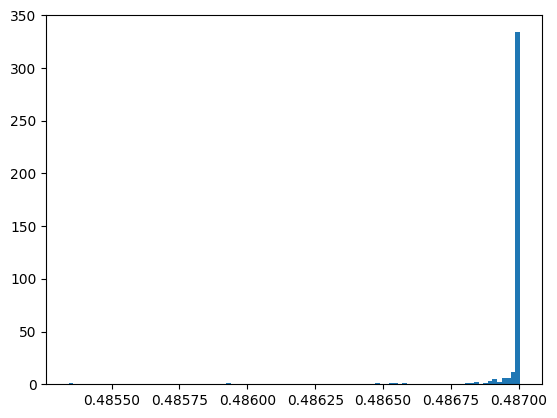

In [25]:
_ = plt.hist(valid_ratio, bins=100)

## Corr(k,k+1) limpia por segmento

In [ ]:
RNG = np.random.default_rng(42)

# Muestreo de vegetación para controlar RAM
veg_coords = np.column_stack(np.where(veg_mask.values))
n_veg = veg_coords.shape[0]
n_sample = max(5000, int(0.02 * n_veg))
idx_sel = RNG.choice(n_veg, size=n_sample, replace=False)
ys, xs = veg_coords[idx_sel, 0], veg_coords[idx_sel, 1]

# Extrae espectros (N, B)
spec_stack = refl_byx.isel(y=xr.DataArray(ys, dims="points"),
                           x=xr.DataArray(xs, dims="points")).transpose("points","band")
X = spec_stack.astype("float32").values

adj_clean = pd.read_csv(REPORTS_DIR + "/adjacent_corr_by_segment.csv")


In [59]:
X

array([[3.8000002e-07, 3.7000001e-07, 3.5000002e-07, ..., 3.1700001e-06,
        3.4299999e-06, 3.4899999e-06],
       [8.5000005e-07, 8.9999997e-07, 9.3000000e-07, ..., 2.5300001e-06,
        2.9999999e-06, 3.1400000e-06],
       [6.2000004e-07, 6.0000002e-07, 6.0000002e-07, ..., 2.0500001e-06,
        2.1000001e-06, 2.1400001e-06],
       ...,
       [6.6999996e-07, 6.6000001e-07, 6.6999996e-07, ..., 2.9300002e-06,
        4.4700000e-06, 5.7699999e-06],
       [5.7000000e-07, 6.0000002e-07, 6.0999997e-07, ..., 1.9200002e-06,
        1.6900000e-06, 1.5300000e-06],
       [5.7000000e-07, 6.0000002e-07, 6.4000000e-07, ..., 2.8000002e-06,
        2.6700000e-06, 2.3499999e-06]], shape=(122559, 379), dtype=float32)

In [60]:
ys, xs

(array([2793, 1754, 2876, ..., 1185, 1653, 2153], shape=(122559,)),
 array([2007, 1848, 3143, ..., 1593, 1376, 2530], shape=(122559,)))

## Función para selección de bandas por segmento espectral

In [62]:
def select_bands(
    wavelengths: np.ndarray,          # shape (B,) en nm
    snr: np.ndarray,                  # shape (B,)
    valid_ratio: np.ndarray,          # shape (B,)
    segments: list,                   # [(a,b), ...] índices de banda, INCLUSIVOS
    X: np.ndarray,                    # espectros muestreados (N, B) para corr a pares
    *,
    verbose: bool = True,
    print_every: int = 50,
    # --- Parámetros actualizados con evidencia de decorrelación ---
    L_target_nm: dict = None,         # espaciamiento principal por segmento
    L_fine_windows: dict = None,      # multiescala: seg_id -> [{"wl_min":..., "wl_max":..., "L":...}, ...]
    MARGIN_NEAR_GAPS: dict = None,    # seg_id -> (left_cut_nm, right_cut_nm)
    MAX_PAIR_CORR_SEG: dict = None,   # seg_id -> umbral corr
    SNR_Q_SEG: float = 0.25,          # cuantil de SNR por segmento
    MIN_VALID_BASE: float = 0.45,     # piso de cobertura
    MIN_PAIR_VALID: int = 50,         # mínimo n para calcular corr a pares
    SPACING_FACTOR: dict = None,      # seg_id -> factor para L (p.ej., 0.85)
    # Anchors fisiológicas (nm) y parámetros
    anchors_nm: dict = None,          # nombre índice -> lista de nm canónicas
    anchor_tol_nm: float = 25.0,      # tolerancia en nm para mapear a banda más cercana
    anchor_relax_valid: float = 0.35, # cobertura mínima relajada para anchors
    anchor_relax_snr_q: float = 0.10, # SNR mínimo relajado para anchors: Q10 segmental
    red_edge_bonus_max: float = 0.20  # bonus máx en score dentro de 680–750 (triangular)
):
    """
    Devuelve:
      sel_df: DataFrame con ['seg_id','band_index','wavelength_nm','snr_proxy','valid_ratio_veg']
      reasons_df: DataFrame con razones de descarte/selección y umbrales efectivos
    """
    B = len(wavelengths)
    assert snr.shape[0] == B and valid_ratio.shape[0] == B, "snr/valid_ratio deben tener longitud B"
    assert X.shape[1] == B, "X debe tener forma (N, B)"
    wavelengths = np.asarray(wavelengths).astype(float)

    # ------------------- Parámetros por defecto (si no vienen) -------------------
    if L_target_nm is None:
        # Ajustados a tus nuevos L90/L95:
        # seg0 multiescala (principal ~38 nm y fino en 680–750 nm ~18 nm)
        L_target_nm = {0: 38.0, 1: 50.0, 2: 60.0, 3: 70.0, 4: 7.0}
    if L_fine_windows is None:
        L_fine_windows = {
            # Ventana red-edge con L fino para capturar pendiente de clorofila
            0: [{"wl_min": 680.0, "wl_max": 750.0, "L": 18.0}]
        }
    if MARGIN_NEAR_GAPS is None:
        # Márgenes asimétricos que ya usabas
        MARGIN_NEAR_GAPS = {3: (15.0, 10.0), 4: (36.0, 20.0)}
    if MAX_PAIR_CORR_SEG is None:
        # Endurecido levemente en seg0–3 dado el sobremuestreo extremo observado
        MAX_PAIR_CORR_SEG = {0: 0.9990, 1: 0.9990, 2: 0.9990, 3: 0.9990, 4: 0.98}
    if SPACING_FACTOR is None:
        # Más estricto en seg1–3; estándar en seg0 y fino en seg4
        SPACING_FACTOR = {0: 0.85, 1: 0.90, 2: 0.90, 3: 0.90, 4: 0.85}
    if anchors_nm is None:
        anchors_nm = {
            "PRI":    [531.0, 570.0],
            "PSRI":   [500.0, 678.0, 750.0],
            "NDRE":   [705.0, 750.0],      # a veces 780–782 nm para NIR
            "CIgreen":[550.0, 782.0]
        }

    # ------------------- Utilidades internas -------------------
    def L_local(seg_id: int, wl: float) -> float:
        """Devuelve el L a usar en esa λ considerando ventanas finas."""
        L = L_target_nm.get(seg_id, 30.0)
        for w in L_fine_windows.get(seg_id, []):
            if w["wl_min"] <= wl <= w["wl_max"]:
                return float(w["L"])
        return float(L)

    def red_edge_bonus(wl: float) -> float:
        """Bonus triangular en 680–750 nm, pico en ~710–720 nm."""
        a, b = 680.0, 750.0
        if wl < a or wl > b:
            return 0.0
        # Triángulo centrado en 715 nm
        center = 715.0
        half = (b - a) / 2.0  # 35 nm
        # distancia normalizada 0..1
        d = abs(wl - center) / half
        return float(max(0.0, (1 - d)) * red_edge_bonus_max)

    def nearest_band(target_nm: float, idx_range: np.ndarray) -> int | None:
        """Devuelve índice de banda más cercana al target dentro de idx_range, o None si vacío."""
        if idx_range.size == 0:
            return None
        idx = idx_range[np.argmin(np.abs(wavelengths[idx_range] - target_nm))]
        return int(idx)

    # ------------------- Salidas -------------------
    selected_rows = []
    reasons_rows  = []

    if verbose:
        print("[INFO] Parámetros:")
        print(f"       L_target_nm: {L_target_nm}")
        print(f"       L_fine_windows: {L_fine_windows}")
        print(f"       MARGIN_NEAR_GAPS: {MARGIN_NEAR_GAPS}")
        print(f"       MAX_PAIR_CORR_SEG: {MAX_PAIR_CORR_SEG}")
        print(f"       SPACING_FACTOR: {SPACING_FACTOR}")
        print(f"       SNR_Q_SEG: Q{int(SNR_Q_SEG*100)} segmental; MIN_VALID_BASE={MIN_VALID_BASE}; MIN_PAIR_VALID={MIN_PAIR_VALID}")
        print(f"       anchors_nm: {anchors_nm} | tol={anchor_tol_nm} nm | relax valid={anchor_relax_valid}, snr Q={anchor_relax_snr_q}")

    # ------------------- Iteración por segmentos -------------------
    for seg_id, (seg_a, seg_b) in enumerate(segments):
        # Asegurar inclusividad
        a = int(seg_a); b = int(seg_b)
        if b < a:
            continue

        wl_start = float(wavelengths[a])
        wl_end   = float(wavelengths[b])
        L_main   = float(L_target_nm.get(seg_id, 30.0))
        left_cut, right_cut = MARGIN_NEAR_GAPS.get(seg_id, (0.0, 0.0))
        spacing_factor = float(SPACING_FACTOR.get(seg_id, 0.85))
        MAX_PAIR_CORR  = float(MAX_PAIR_CORR_SEG.get(seg_id, 0.99))

        seg_idx = np.arange(a, b + 1)
        seg_wl  = wavelengths[seg_idx]
        seg_snr = snr[seg_idx]
        seg_valid = valid_ratio[seg_idx]

        # Umbrales adaptativos por segmento
        snr_q_seg  = np.nanquantile(seg_snr, SNR_Q_SEG)
        snr_q10_seg = np.nanquantile(seg_snr, 0.10)  # para anchors relajados
        valid_q25_seg = np.nanquantile(seg_valid, 0.25)
        MIN_VALID_SEG = max(MIN_VALID_BASE, float(valid_q25_seg))

        if verbose:
            print(f"\n[SEG {seg_id}] λ≈{wl_start:.1f}–{wl_end:.1f} nm | bandas={b-a+1} | L_main={L_main:.1f} nm "
                  f"| margins=({left_cut:.1f},{right_cut:.1f}) nm | spacing≥{spacing_factor:.2f}·L | "
                  f"SNR≥Q{int(SNR_Q_SEG*100)}={snr_q_seg:.3f} | valid≥{MIN_VALID_SEG:.0%}")

        # 1) Filtro duro: márgenes, valid_ratio, SNR (segmentales)
        cand = []
        for i in seg_idx:
            wl_i = float(wavelengths[i])
            # márgenes cerca de bordes del segmento
            if (wl_i - wl_start) < left_cut:
                reasons_rows.append({"seg_id": seg_id, "band_index": i, "reason": "near_left_gap",
                                     "wl_nm": wl_i, "L": L_main, "min_valid": MIN_VALID_SEG, "snr_q": snr_q_seg})
                continue
            if (wl_end - wl_i) < right_cut:
                reasons_rows.append({"seg_id": seg_id, "band_index": i, "reason": "near_right_gap",
                                     "wl_nm": wl_i, "L": L_main, "min_valid": MIN_VALID_SEG, "snr_q": snr_q_seg})
                continue
            # cobertura / SNR
            if (not np.isfinite(valid_ratio[i])) or (valid_ratio[i] < MIN_VALID_SEG):
                reasons_rows.append({"seg_id": seg_id, "band_index": i, "reason": "low_valid",
                                     "wl_nm": wl_i, "valid": float(valid_ratio[i]) if np.isfinite(valid_ratio[i]) else np.nan,
                                     "min_valid": MIN_VALID_SEG})
                continue
            if (not np.isfinite(snr[i])) or (snr[i] < snr_q_seg):
                reasons_rows.append({"seg_id": seg_id, "band_index": i, "reason": "low_snr",
                                     "wl_nm": wl_i, "snr": float(snr[i]) if np.isfinite(snr[i]) else np.nan,
                                     "snr_q": snr_q_seg})
                continue
            cand.append(i)

        if verbose:
            print(f"[SEG {seg_id}] Candidatas tras filtros: {len(cand)} / {b-a+1} "
                  f"(≥{MIN_VALID_SEG:.0%} válidos & SNR≥Q{int(SNR_Q_SEG*100)})")

        if len(cand) == 0:
            if verbose:
                print(f"[SEG {seg_id}] ⚠️  Sin candidatas, se omite segmento.")
            continue

        # 2) Score por SNR + valid_ratio + bonus red-edge (dentro del segmento)
        def score(i: int) -> float:
            s = snr[i]
            v = valid_ratio[i]
            wl_i = float(wavelengths[i])
            # z-scores segmentales simples (evitar NaN)
            s_norm = (s - np.nanmean(seg_snr)) / (np.nanstd(seg_snr) + 1e-6)
            v_norm = (v - np.nanmean(seg_valid)) / (np.nanstd(seg_valid) + 1e-6)
            return (s_norm + 0.5 * v_norm) + red_edge_bonus(wl_i)

        order = sorted(cand, key=score, reverse=True)
        if verbose:
            preview = [(int(i), float(wavelengths[i]), float(snr[i]),
                        float(valid_ratio[i])) for i in order[:min(5, len(order))]]
            print(f"[SEG {seg_id}] Top-5 por score (idx, nm, SNR, valid): {preview}")

        # 3) Pre-selección de anchors (forzadas con filtros relajados)
        keep = []
        # idx válidos del segmento para anchors
        seg_idx_arr = np.array(seg_idx, dtype=int)

        # construir lista de nm a anclar que caen en este segmento (por límites espectrales)
        anchors_targets = []
        for name, nm_list in anchors_nm.items():
            for t in nm_list:
                if wl_start - anchor_tol_nm <= t <= wl_end + anchor_tol_nm:
                    anchors_targets.append((name, float(t)))

        for name, target_nm in anchors_targets:
            # banda más cercana dentro del segmento
            bi = nearest_band(target_nm, seg_idx_arr)
            if bi is None:
                continue
            wl_i = float(wavelengths[bi])
            # tolerancia
            if abs(wl_i - target_nm) > anchor_tol_nm:
                continue
            # chequear márgenes
            if (wl_i - wl_start) < left_cut or (wl_end - wl_i) < right_cut:
                continue
            # chequear filtros relajados
            v_i = valid_ratio[bi]; s_i = snr[bi]
            if not np.isfinite(v_i) or v_i < anchor_relax_valid:
                continue
            if not np.isfinite(s_i) or s_i < max(snr_q10_seg, 0.0):
                continue
            # backstop de correlación vs vecindad existente
            L_i = L_local(seg_id, wl_i)
            # Vecindad: |Δλ| < 0.5·L_i
            neighbors = [j for j in keep if abs(float(wavelengths[j]) - wl_i) < 0.5 * L_i]
            ok = True
            for j in neighbors:
                a_i, a_j = X[:, bi], X[:, j]
                m = np.isfinite(a_i) & np.isfinite(a_j)
                n = int(m.sum())
                if n > MIN_PAIR_VALID:
                    c = np.corrcoef(a_i[m], a_j[m])[0, 1]
                    if c > MAX_PAIR_CORR:
                        ok = False
                        reasons_rows.append({"seg_id": seg_id, "band_index": bi,
                                             "reason": f"anchor_pair_corr>{MAX_PAIR_CORR}",
                                             "wl_nm": wl_i, "n_valid": n, "corr": float(c)})
                        break
            if ok and bi not in keep:
                keep.append(bi)
                reasons_rows.append({"seg_id": seg_id, "band_index": bi, "reason": "forced_anchor",
                                     "anchor_nm": target_nm, "wl_nm": wl_i, "snr": float(s_i),
                                     "valid": float(v_i)})

        # 4) Selección greedy con espaciamiento y backstop de correlación en vecindad
        evaluated = 0
        for i in order:
            if i in keep:
                continue
            wl_i = float(wavelengths[i])
            L_i = L_local(seg_id, wl_i)
            # Espaciamiento: min distancia en λ a lo ya seleccionado
            if keep:
                min_d = min(abs(wl_i - float(wavelengths[j])) for j in keep)
                if min_d < spacing_factor * L_i:
                    reasons_rows.append({"seg_id": seg_id, "band_index": i, "reason": "spacing",
                                         "wl_nm": wl_i, "min_dist_nm": float(min_d),
                                         "required_nm": float(spacing_factor * L_i)})
                    evaluated += 1
                    if verbose and (evaluated % print_every == 0):
                        print(f"[SEG {seg_id}] Evaluadas {evaluated}/{len(order)}... descarta por spacing: "
                              f"idx {i}, λ={wl_i:.1f} nm (min_d={min_d:.1f} < {spacing_factor*L_i:.1f})")
                    continue
            # Backstop de correlación SOLO con vecindad
            neighbors = [j for j in keep if abs(float(wavelengths[j]) - wl_i) < 0.5 * L_i]
            ok = True
            for j in neighbors:
                a_i, a_j = X[:, i], X[:, j]
                m = np.isfinite(a_i) & np.isfinite(a_j)
                n = int(m.sum())
                if n > MIN_PAIR_VALID:
                    c = np.corrcoef(a_i[m], a_j[m])[0, 1]
                    if c > MAX_PAIR_CORR:
                        ok = False
                        reasons_rows.append({"seg_id": seg_id, "band_index": i,
                                             "reason": f"pair_corr>{MAX_PAIR_CORR}",
                                             "wl_nm": wl_i, "neighbor_idx": int(j),
                                             "neighbor_wl_nm": float(wavelengths[j]),
                                             "n_valid": n, "corr": float(c)})
                        break
                else:
                    reasons_rows.append({"seg_id": seg_id, "band_index": i,
                                         "reason": "pair_corr_skipped_n<=MIN",
                                         "wl_nm": wl_i, "neighbor_idx": int(j),
                                         "neighbor_wl_nm": float(wavelengths[j]),
                                         "n_valid": n})
            if ok:
                keep.append(i)
                if verbose:
                    print(f"[SEG {seg_id}] ✅ Seleccionada: idx {i} | λ={wl_i:.1f} nm | "
                          f"SNR={float(snr[i]):.3f} | valid={float(valid_ratio[i]):.2%} | sel_seg={len(keep)}")

            evaluated += 1
            if verbose and (evaluated % print_every == 0):
                print(f"[SEG {seg_id}] Progreso: {evaluated}/{len(order)} evaluadas, {len(keep)} elegidas.")

        # 5) Persistir selección del segmento
        keep_sorted = sorted(set(keep))
        for i in keep_sorted:
            selected_rows.append({
                "seg_id": seg_id,
                "band_index": int(i),
                "wavelength_nm": float(wavelengths[i]),
                "snr_proxy": float(snr[i]) if np.isfinite(snr[i]) else np.nan,
                "valid_ratio_veg": float(valid_ratio[i]) if np.isfinite(valid_ratio[i]) else np.nan
            })

        if verbose:
            if keep_sorted:
                print(f"[SEG {seg_id}] ✔️  Seleccionadas: {len(keep_sorted)} "
                      f"(λ: {float(wavelengths[keep_sorted[0]]):.1f}–{float(wavelengths[keep_sorted[-1]]):.1f} nm)")
            else:
                print(f"[SEG {seg_id}] ⚠️  No se seleccionaron bandas.")

        # 6) Trazabilidad de umbrales efectivos (como reasons 'params')
        reasons_rows.append({"seg_id": seg_id, "band_index": -1, "reason": "params",
                             "L_main": L_main, "spacing_factor": spacing_factor,
                             "left_cut": left_cut, "right_cut": right_cut,
                             "snr_q_seg": float(snr_q_seg), "valid_min_seg": float(MIN_VALID_SEG),
                             "max_pair_corr": MAX_PAIR_CORR})

    sel_df = pd.DataFrame(selected_rows).sort_values(["seg_id", "wavelength_nm"]).reset_index(drop=True)
    reasons_df = pd.DataFrame(reasons_rows)
    return sel_df, reasons_df

sel_df, reasons_df = select_bands(wavelengths, snr, valid_ratio, segments, X, verbose=True)

[INFO] Parámetros:
       L_target_nm: {0: 38.0, 1: 50.0, 2: 60.0, 3: 70.0, 4: 7.0}
       L_fine_windows: {0: [{'wl_min': 680.0, 'wl_max': 750.0, 'L': 18.0}]}
       MARGIN_NEAR_GAPS: {3: (15.0, 10.0), 4: (36.0, 20.0)}
       MAX_PAIR_CORR_SEG: {0: 0.999, 1: 0.999, 2: 0.999, 3: 0.999, 4: 0.98}
       SPACING_FACTOR: {0: 0.85, 1: 0.9, 2: 0.9, 3: 0.9, 4: 0.85}
       SNR_Q_SEG: Q25 segmental; MIN_VALID_BASE=0.45; MIN_PAIR_VALID=50
       anchors_nm: {'PRI': [531.0, 570.0], 'PSRI': [500.0, 678.0, 750.0], 'NDRE': [705.0, 750.0], 'CIgreen': [550.0, 782.0]} | tol=25.0 nm | relax valid=0.35, snr Q=0.1

[SEG 0] λ≈411.0–914.0 nm | bandas=174 | L_main=38.0 nm | margins=(0.0,0.0) nm | spacing≥0.85·L | SNR≥Q25=1.810 | valid≥49%
[SEG 0] Candidatas tras filtros: 129 / 174 (≥49% válidos & SNR≥Q25)
[SEG 0] Top-5 por score (idx, nm, SNR, valid): [(1, 413.9390869140625, 3.304166, 0.487002625748227), (2, 416.8463439941406, 3.2435493, 0.487002625748227), (3, 419.7536315917969, 3.1265423, 0.48700262574822

Con esta configuración, el proceso ha seleccionado pocas bandas para los seg1 a seg3 por lo cual modifico para probar un ajuste menos estricto en esos segmentos.

In [63]:
reasons_df.query("seg_id in [1,2,3]").reason.value_counts()

reason
spacing           71
low_snr           30
params             3
near_left_gap      3
low_valid          3
near_right_gap     2
Name: count, dtype: int64

### Variación de parámetros

In [64]:
params_override = dict(
    # 1) Espaciamiento: bajar L_target y factor en seg1–seg3
    L_target_nm = {0: 38.0, 1: 35.0, 2: 40.0, 3: 50.0, 4: 7.0},
    SPACING_FACTOR = {0: 0.85, 1: 0.7, 2: 0.7, 3: 0.7, 4: 0.85},

    # 2) SNR por segmento: relajar
    SNR_Q_SEG = 0.15, 

    # 3) Mantener márgenes y cobertura (opcionales de ajuste fino)
    MIN_VALID_BASE = 0.45,  
    MARGIN_NEAR_GAPS = {3: (15.0, 10.0), 4: (36.0, 20.0)}
)


anchors_nm = {
    "PRI":    [531.0, 570.0],
    "PSRI":   [500.0, 678.0, 750.0],
    "NDRE":   [705.0, 750.0],
    "CIgreen":[550.0, 782.0]
}


sel_df, reasons_df = select_bands(
    wavelengths, snr, valid_ratio, segments, X,
    L_target_nm=params_override["L_target_nm"],
    SPACING_FACTOR=params_override["SPACING_FACTOR"],
    SNR_Q_SEG=params_override["SNR_Q_SEG"],
    MIN_VALID_BASE=params_override["MIN_VALID_BASE"],
    MARGIN_NEAR_GAPS=params_override["MARGIN_NEAR_GAPS"],
    anchors_nm=anchors_nm,
    anchor_tol_nm=25.0,
    anchor_relax_valid=0.35,
    anchor_relax_snr_q=0.10,
    verbose=True
)

[INFO] Parámetros:
       L_target_nm: {0: 38.0, 1: 35.0, 2: 40.0, 3: 50.0, 4: 7.0}
       L_fine_windows: {0: [{'wl_min': 680.0, 'wl_max': 750.0, 'L': 18.0}]}
       MARGIN_NEAR_GAPS: {3: (15.0, 10.0), 4: (36.0, 20.0)}
       MAX_PAIR_CORR_SEG: {0: 0.999, 1: 0.999, 2: 0.999, 3: 0.999, 4: 0.98}
       SPACING_FACTOR: {0: 0.85, 1: 0.7, 2: 0.7, 3: 0.7, 4: 0.85}
       SNR_Q_SEG: Q15 segmental; MIN_VALID_BASE=0.45; MIN_PAIR_VALID=50
       anchors_nm: {'PRI': [531.0, 570.0], 'PSRI': [500.0, 678.0, 750.0], 'NDRE': [705.0, 750.0], 'CIgreen': [550.0, 782.0]} | tol=25.0 nm | relax valid=0.35, snr Q=0.1

[SEG 0] λ≈411.0–914.0 nm | bandas=174 | L_main=38.0 nm | margins=(0.0,0.0) nm | spacing≥0.85·L | SNR≥Q15=1.655 | valid≥49%
[SEG 0] Candidatas tras filtros: 147 / 174 (≥49% válidos & SNR≥Q15)
[SEG 0] Top-5 por score (idx, nm, SNR, valid): [(1, 413.9390869140625, 3.304166, 0.487002625748227), (2, 416.8463439941406, 3.2435493, 0.487002625748227), (3, 419.7536315917969, 3.1265423, 0.48700262574822

In [65]:
reasons_df.query("seg_id in [1,2,3]").reason.value_counts()

reason
spacing           74
low_snr           18
params             3
near_left_gap      3
low_valid          3
near_right_gap     2
Name: count, dtype: int64

In [66]:
sel_df 

,seg_id,band_index,wavelength_nm,snr_proxy,valid_ratio_veg
0,0,1,413.939087,3.304166,0.487003
1,0,13,448.826294,1.699654,0.487003
2,0,31,501.157135,1.718806,0.487003
3,0,41,530.229797,1.925885,0.487003
4,0,48,550.580688,1.919247,0.487003
5,0,55,570.931580,1.952280,0.487003
6,0,67,605.818787,1.910738,0.487003
7,0,79,640.705994,1.738496,0.487003
8,0,101,704.665894,2.085348,0.487003
9,0,107,722.109497,2.009879,0.487003


In [67]:
reasons_df[reasons_df["wl_nm"].between(660.0, 690.0)]

,seg_id,band_index,reason,wl_nm,valid,min_valid,snr,snr_q,anchor_nm,n_valid,...,min_dist_nm,required_nm,L_main,spacing_factor,left_cut,right_cut,snr_q_seg,valid_min_seg,max_pair_corr,L
17,0,86,low_snr,661.056885,NaN,NaN,1.543186,1.655172,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,0,87,low_snr,663.964172,NaN,NaN,1.522545,1.655172,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,0,88,low_snr,666.871399,NaN,NaN,1.506539,1.655172,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,0,89,low_snr,669.778687,NaN,NaN,1.495362,1.655172,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,0,90,low_snr,672.685974,NaN,NaN,1.490856,1.655172,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,0,91,low_snr,675.593201,NaN,NaN,1.489234,1.655172,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,0,92,low_snr,678.500488,NaN,NaN,1.496125,1.655172,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,0,93,low_snr,681.407776,NaN,NaN,1.512933,1.655172,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,0,94,low_snr,684.315002,NaN,NaN,1.559314,1.655172,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,0,95,low_snr,687.222290,NaN,NaN,1.645101,1.655172,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [68]:
sel_df.to_csv(INTERIM_DATA + "/bands_selected_by_segment.csv", index=False)
reasons_df.to_csv(INTERIM_DATA + "/bands_selection_reasons.csv", index=False)

# Selección final de bandas espectrales

Para reducir la redundancia espectral y preservar la información relevante para la detección de deficiencia de fósforo en frijol, se implementó un procedimiento de selección de bandas basado en análisis previos de correlación adyacente, longitud de decorrelación (L90/L95) y relación señal/ruido (SNR). Estos análisis mostraron que los segmentos VNIR–NIR–SWIR1 presentan sobremuestreo extremo (correlaciones >0.99 incluso con separaciones >120 nm), mientras que el segmento SWIR2 exhibe decorrelación rápida (L90≈6.3 nm), lo que justifica mantener alta densidad espectral en esta región.
Con base en estos hallazgos, se definieron los siguientes criterios:

- Espaciamiento objetivo por segmento (L_target): seg0=38 nm, seg1=35 nm, seg2=40 nm, seg3=50 nm, seg4=7 nm.
- Espaciamiento mínimo efectivo: ≥ SPACING_FACTOR·L_local(λ) (seg0=0.85; seg1–3=0.70; seg4=0.85), permitiendo mayor densidad en seg1–3 para incrementar muestreo.
- Filtros duros: cobertura mínima en vegetación (valid_ratio ≥ max(0.45, Q25_seg)) y SNR ≥ Q15 segmental.
- Márgenes asimétricos contra los bordes de las ventanas de absorción del agua (± 1.4 y 1.9 µm).
- Backstop de colinealidad: descartar candidatos con correlación a pares > 0.999 (seg0–3) o > 0.98 (seg4), evaluada solo en vecindad espectral (|Δλ| < 0.5·L_local).
- Anclas fisiológicas: garantizar bandas cercanas a 531/550/570 nm (PRI, CIgreen), 705/750/782 nm (NDRE), y 500 nm (PSRI), priorizando su inclusión con filtros relajados cuando fue necesario.

La selección final resultó en 58 bandas distribuidas por segmento:

- VNIR/red-edge (seg0): 15 bandas (413–914 nm), incluyendo anclas para PRI, CIgreen y NDRE.
- NIR (seg1): 5 bandas (1011–1113 nm), equiespaciadas (~24–26 nm).
- SWIR1 (seg2): 6 bandas (1159–1328 nm), espaciadas ~30–35 nm.
- SWIR1b (seg3): 8 bandas (1497–1773 nm), respetando márgenes frente al gap de 1.9 µm.
- SWIR2 (seg4): 24 bandas (2060–2428 nm), con alta densidad (~6–10 nm) acorde con su rápida decorrelación y relevancia bioquímica (agua, estructura celular).

Esta configuración reduce el número total de variables respecto al cubo original (379 bandas), minimiza redundancia en segmentos sobremuestreados y preserva dominios espectrales críticos para el objetivo del estudio. Además, garantiza la posibilidad de calcular índices fisiológicos relevantes (PRI, NDRE, CIgreen) y mantiene la densidad necesaria en SWIR2 para capturar variaciones sutiles asociadas a la composición bioquímica. Todos los parámetros utilizados (espaciamientos, factores, cuantiles, márgenes y umbrales) fueron registrados junto con las salidas de selección, asegurando reproducibilidad del proceso.